In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

import collections

from dm_control import mujoco, viewer, suite
from dm_control.rl import control
from dm_control.suite import base, common
from dm_control.suite.utils import randomizers
from dm_control.utils import rewards
from dm_control.utils import io as resources
from dm_env import specs
import numpy as np
import os

from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

import random

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

# Guassian Mixture Reward:

In [2]:
def gaussian_nd(x, mu, sigma):
    D = mu.shape[0]
    inv_sigma = torch.inverse(sigma)  # Compute the inverse covariance matrix
    det_sigma = torch.det(sigma)  # Compute the determinant of the covariance matrix

    diff = x - mu  # Shape: (N, D)
    exponent = -0.5 * torch.sum(diff @ inv_sigma * diff, dim=1)  # Shape: (N,)

    normalization_constant = (2 * torch.pi) ** (D / 2) * torch.sqrt(det_sigma)
    normalization_constant = 1
    
    return torch.exp(exponent) / normalization_constant
    
    
class GuassianMixtureReward:
    def __init__(self, obs_dim, num_guassians, from_buffer):
        self.obs_dim = obs_dim
        self.num_guassians = num_guassians
        self.len_params = num_guassians * 2 * self.obs_dim
        
        self.from_buffer = from_buffer
        self.buffer = []
        self.std = 1
        
        
    def add(self, obs):
        assert len(obs.shape) == 2
        assert obs.shape[1] == self.obs_dim
        
        for i in range(len(obs)):
            self.buffer.append(obs[i].cpu())
            
        random_samples = torch.stack([random.choice(self.buffer) for _ in range(1000)])
        std = random_samples.std(dim=0)
        self.std = std
        # self.std = torch.ones_like(std)

    
    def tensor2list(self, tensor_param):
        # tensor_param.shape == (batch_size, len_params)
        assert len(tensor_param.shape) == 2
        assert tensor_param.shape[1] == self.len_params
        
        batch_size = tensor_param.shape[0]
        obs_dim = self.obs_dim
        
        res = []
        for b in range(batch_size):
            list_param = []
            for i in range(0, len(tensor_param[b]), obs_dim*2):
                mu = tensor_param[b] [i:i+obs_dim]
                var = tensor_param[b][i+obs_dim:i + obs_dim*2]
                list_param.append((mu, var))
            res.append(list_param)
        # print(res)
        return res
    
    
    def one_random_sample(self):
        params = []
        info = []
        for _  in range(self.num_guassians):
            if self.from_buffer:
                if self.buffer:
                    mu = random.choice(self.buffer)
                    mu = mu + torch.normal(0, 1, (2,))*self.std
                else:
                    mu = torch.normal(0, 1, (self.obs_dim,))
            else:
                # mu = torch.rand(self.obs_dim)
                mu = torch.rand(2) * 0.6 - 0.3
                # mu[:2] = torch.tensor([0.25, 0.25])
                # mu[2:] = torch.rand(2) * 0.1 - 0.05
                
            
            var = torch.rand(self.obs_dim) * 0.1
            # var = torch.full_like(var, fill_value=0.05)
            
            params.append(mu)
            params.append(var)
            info.append({'mu':mu, 'var':var})
        return torch.concatenate(params), info
    
    
    def sample(self, N):
        params_stack = []
        info_stack = []
        for _ in range(N):
            params, info = self.one_random_sample()
            params_stack.append(params)
            info_stack.append(info)
            
        params_stack = torch.stack(params_stack)
        return params_stack.to(device), info_stack
    
    
    
    def get_reward_2(self, obs, params):
        # obs.shape == (batch_size, obs_len)
        # params.shape == (batch_size, len_params)
        assert obs.shape[0] == params.shape[0]
        assert len(obs.shape) == 2 
        assert params.shape[1] == self.len_params
        
        params_mu_var = self.tensor2list(params)
        
        
        mu = torch.stack([torch.stack([mu for (mu, var) in mu_var]) for mu_var in params_mu_var])
        var = torch.stack([torch.stack([var for (mu, var) in mu_var]) for mu_var in params_mu_var])
                
        res = 0
                
        for i in range(self.num_guassians):
            
            m, v = mu[:, i, :], var[:, i, :]
            inv_sigma = torch.stack([torch.diag(1 / row) for row in v])
            
            diff = obs - m
            exponent = -0.5 * (diff.unsqueeze(-2) @ inv_sigma) @ diff.unsqueeze(-1)

            res += torch.exp(exponent).flatten()
        
        return res
    
    def get_tensor_mu_inv_sigma(self, params):
        params_mu_var = self.tensor2list(params)
        mu = torch.stack([torch.stack([mu for (mu, var) in mu_var]) for mu_var in params_mu_var]).to(device)
        var = torch.stack([torch.stack([var for (mu, var) in mu_var]) for mu_var in params_mu_var])
        inv_sigma = torch.stack([torch.stack([torch.diag(1 / v) for v in var_]) for var_ in var]).to(device)
        return mu, inv_sigma
    
    def get_reward(self, obs, params, mu=None, inv_sigma=None):
        # obs.shape == (batch_size, obs_len)
        # params.shape == (batch_size, len_params)
        assert obs.shape[0] == params.shape[0]
        assert len(obs.shape) == 2 
        assert params.shape[1] == self.len_params
        
        params_mu_var = self.tensor2list(params)
        
        
        if mu is None:
            mu = torch.stack([torch.stack([mu for (mu, var) in mu_var]) for mu_var in params_mu_var])
        
        if inv_sigma is None:
            var = torch.stack([torch.stack([var for (mu, var) in mu_var]) for mu_var in params_mu_var])
            inv_sigma = torch.stack([torch.stack([torch.diag(1 / v) for v in var_]) for var_ in var])

        diff = (obs.unsqueeze(1).repeat(1, self.num_guassians, 1) - mu)
                
        exponent = -0.5 * ((diff.unsqueeze(-2) @ inv_sigma) @ diff.unsqueeze(-1)).squeeze(-1).squeeze(-1)
        
        res = torch.exp(exponent).sum(axis=-1)
        
        return res
        
    
# test = GuassianMixtureReward(obs_dim=2, num_guassians=1, from_buffer=False)

# params, _ = test.sample(128)

# mu, inv_sigma = test.get_tensor_mu_inv_sigma(params)

# for _ in tqdm(range(1000)):

#     obs = torch.rand(128, 2).to(device)
#     res = test.get_reward(obs, params, mu, inv_sigma)

# Reward Generator:

In [3]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            # nn.Linear(512, 512),
            # nn.LayerNorm(512),
            # nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, states, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        state_emb = self.state_embed(states)        

        w_pre = self.encoder_transformer(state_emb, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [4]:
fre_network = FRENetwork(obs_len=2)
fre_network.load_state_dict(torch.load('models/reward_generator.pth'))
statistics = torch.load('models/reward_generator_mean_std.pth')
emperical_mean = statistics['emperical_mean']
emperical_std = statistics['emperical_std']

/tmp/ipykernel_13239/1798895976.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fre_network.load_state_dict(torch.load('models/reward_generator.pth'))
/tmp/ipykernel_132

In [5]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network, emperical_mean, emperical_std, from_buffer):
        self.obs_dim = obs_dim
        self.fre_network = fre_network.to(device)
        self.emperical_mean = emperical_mean.to(device)
        self.emperical_std = emperical_std.to(device)
        
        self.from_buffer = from_buffer
        self.buffer = []
        self.std = 1
        
        
    def add(self, obs):
        assert len(obs.shape) == 2
        assert obs.shape[1] == self.obs_dim
        
        for i in range(len(obs)):
            self.buffer.append(obs[i].cpu())
            
        random_samples = torch.stack([random.choice(self.buffer) for _ in range(1000)])
        std = random_samples.std(dim=0)
        self.std = std
        # self.std = torch.ones_like(std)
            
        
    
    def sample(self, N):
        w = self.emperical_mean  + torch.normal(0, 1, (N, self.emperical_mean.shape[0]), device=device) * self.emperical_std
        return w.to(device), {}
    
    
    def get_reward(self, obs, w):
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
        

# params, _ = test.sample(128)

# mu, inv_sigma = test.get_tensor_mu_inv_sigma(params)

# for _ in tqdm(range(1000)):

#     obs = torch.rand(128, 2).to(device)
#     res = test.get_reward(obs, params, mu, inv_sigma)

In [6]:
# test = RewardGenerator(2, fre_network, emperical_mean, emperical_std, from_buffer=False)

# N = 10000
# w, _ = test.sample(1)
# w = w.repeat(N, 1)
# obs = torch.rand((N, 2)) * 0.6 - 0.3

# obs = obs.to(device)
# r = test.get_reward(obs, w)

# plt.scatter(obs[:, 0].cpu(), obs[:, 1].cpu(), c=r.cpu())

# Env:

In [75]:
# TASKS = [
#     ('reach_top_left', np.array([-0.15, 0.15, 0.01])),
#     ('reach_top_right', np.array([0.15, 0.15, 0.01])),
#     ('reach_bottom_left', np.array([-0.15, -0.15, 0.01])),
#     ('reach_bottom_right', np.array([0.15, -0.15, 0.01]))
# ]


# class MultiTaskPointMassMaze(base.Task):
#     """A point_mass `Task` to reach target with smooth reward."""
#     def __init__(self, target_id, random=None):
#         """Initialize an instance of `PointMassMaze`.

#     Args:
#       randomize_gains: A `bool`, whether to randomize the actuator gains.
#       random: Optional, either a `numpy.random.RandomState` instance, an
#         integer seed for creating a new `RandomState`, or None to select a seed
#         automatically (default).
#     """
#         super().__init__(random=random)

#     def initialize_episode(self, physics):
#         """Sets the state of the environment at the start of each episode.

#        If _randomize_gains is True, the relationship between the controls and
#        the joints is randomized, so that each control actuates a random linear
#        combination of joints.

#     Args:
#       physics: An instance of `mujoco.Physics`.
#     """
#         randomizers.randomize_limited_and_rotational_joints(
#             physics, self.random)
#         physics.data.qpos[0] = np.random.uniform(-0.01, 0.01)
#         physics.data.qpos[1] = np.random.uniform(-0.01, 0.01)
#         #import ipdb; ipdb.set_trace()
        

#         super().initialize_episode(physics)

#     def get_observation(self, physics):
#         """Returns an observation of the state."""
#         obs = collections.OrderedDict()
#         obs['position'] = physics.position()
#         obs['velocity'] = physics.velocity()
#         return obs
    
#     def get_reward_spec(self):
#         return specs.Array(shape=(1,), dtype=np.float32, name='reward')

#     def get_reward(self, physics):
#         """Returns a reward to the agent."""
#         reward = -1
#         return reward



# class Physics(mujoco.Physics):
#     """physics for the point_mass domain."""

#     def mass_to_target_dist(self, target):
#         """Returns the distance from mass to the target."""
#         d = target - self.named.data.geom_xpos['pointmass']
#         return np.linalg.norm(d)

In [76]:
# def convert_dm_control_to_gym_space(dm_control_space):
#     r"""Convert dm_control space to gym space. """
#     if isinstance(dm_control_space, specs.BoundedArray):
#         space = spaces.Box(low=dm_control_space.minimum, 
#                            high=dm_control_space.maximum, 
#                            dtype=dm_control_space.dtype)
#         assert space.shape == dm_control_space.shape
#         return space
#     elif isinstance(dm_control_space, specs.Array) and not isinstance(dm_control_space, specs.BoundedArray):
#         space = spaces.Box(low=-float('inf'), 
#                            high=float('inf'), 
#                            shape=dm_control_space.shape, 
#                            dtype=dm_control_space.dtype)
#         return space
#     elif isinstance(dm_control_space, dict):
#         space = spaces.Dict({key: convert_dm_control_to_gym_space(value)
#                              for key, value in dm_control_space.items()})
#         return space


# class DMSuiteEnv(gym.Env):
#     def __init__(self, env):
#         self.env = env
#         self.metadata = {'render.modes': ['human', 'rgb_array'],
#                          'video.frames_per_second': round(1.0/self.env.control_timestep())}

#         self.observation_space = convert_dm_control_to_gym_space(self.env.observation_spec())
#         self.action_space = convert_dm_control_to_gym_space(self.env.action_spec())
#         self.viewer = None
    
#     def seed(self, seed):
#         return self.env.task.random.seed(seed)
    
#     def step(self, action):
#         timestep = self.env.step(action)
#         observation = timestep.observation
#         reward = timestep.reward
#         done = timestep.last()
        
#         # If target found, set done to True:
#         # target_size = 0.015
#         # distance = np.linalg.norm(self.env.physics.named.data.geom_xpos['target'] - self.env.physics.named.data.geom_xpos['pointmass'])
#         # goal_reached = rewards.tolerance(distance, bounds=(0, target_size), margin=target_size)
#         # if goal_reached > 0.9:
#         #     done = True
            
#         info = {}
#         truncated = False
#         return observation, reward, done, truncated, info
    
#     def reset(self, seed=None, options=None):
#         timestep = self.env.reset()
#         return timestep.observation, {}
    
#     def render(self, mode='human', **kwargs):
#         if 'camera_id' not in kwargs:
#             kwargs['camera_id'] = 0  # Tracking camera
#         use_opencv_renderer = kwargs.pop('use_opencv_renderer', False)
        
#         img = self.env.physics.render(**kwargs)
#         if mode == 'rgb_array':
#             return img
#         elif mode == 'human':
#             if self.viewer is None:
#                 if not use_opencv_renderer:
#                     from gym.envs.classic_control import rendering
#                     self.viewer = rendering.SimpleImageViewer(maxwidth=1024)
#                 else:
#                     from . import OpenCVImageViewer
#                     self.viewer = OpenCVImageViewer()
#             self.viewer.imshow(img)
#             return self.viewer.isopen
#         else:
#             raise NotImplementedError

#     def close(self):
#         if self.viewer is not None:
#             self.viewer.close()
#             self.viewer = None
#         return self.env.close()
    
    
# class FlattenObservation(gym.ObservationWrapper):
#     def __init__(self, env):
#         super().__init__(env)
        
#         # Flatten the observation space by combining the shapes of each dictionary entry
#         self.observation_space = gym.spaces.Box(
#             low=-np.inf, 
#             high=np.inf, 
#             shape=(self.flatten_observation_space_shape(),), 
#             dtype=np.float32
#         )

#     def flatten_observation_space_shape(self):
#         # Calculate the total number of elements in the observation space after flattening
#         total_shape = 0
#         for key in self.observation_space.spaces:
#             total_shape += np.prod(self.observation_space.spaces[key].shape)
#         return total_shape

#     def observation(self, obs):
#         # Flatten the dictionary of numpy arrays into a single vector
#         return np.concatenate([obs[key].flatten() for key in obs], axis=0)
    
# def flat_obs(obs):
#     return np.concatenate([obs[key].flatten() for key in obs], axis=0)

In [77]:
# target_id = 1

# xml = resources.GetResource(f'mazes/point_mass_maze_empty.xml')
# physics = Physics.from_xml_string(xml, common.ASSETS)
# task = MultiTaskPointMassMaze(target_id=target_id)

# dm_env = control.Environment(
#     physics,
#     task,
#     time_limit=20,
# )

# viewer.launch(dm_env)

# Jax ENV:

In [78]:
import jax
import jax.numpy as jnp
from brax import base
from brax.envs.base import PipelineEnv, State
from brax.io import mjcf
from etils import epath
import jax
from jax import numpy as jp


class PointMaze(PipelineEnv):

    def __init__(self):

        backend='mjx' #'generalized'
        kwargs={}
        
        path = 'mazes/point_mass_maze_empty.xml'
        sys = mjcf.load(path)
        
        n_frames = 1
        kwargs['n_frames'] = kwargs.get('n_frames', n_frames)
        super().__init__(sys=sys, backend=backend, **kwargs)
        
        # path = epath.resource_path('brax') / 'envs/assets/half_cheetah.xml'
        
        
    def reset(self, rng: jax.Array) -> State:
        """Resets the environment to an initial state."""
        rng, rng1, rng2 = jax.random.split(rng, 3)

        _reset_noise_scale = 0.001

        low, hi = -_reset_noise_scale, _reset_noise_scale
        qpos = self.sys.init_q + jax.random.uniform(
            rng1, (self.sys.q_size(),), minval=low, maxval=hi
        )
        qvel = hi * jax.random.normal(rng2, (self.sys.qd_size(),))
        
        pipeline_state = self.pipeline_init(qpos, qvel)

        
        obs = self._get_obs(pipeline_state)
        reward, done, zero = jp.zeros(3)
        metrics = {
            'x_position': zero,
            'y_position': zero,
        }
        return State(pipeline_state, obs, reward, done, metrics)
    
    def step(self, state: State, action: jax.Array) -> State:
        pipeline_state0 = state.pipeline_state
        assert pipeline_state0 is not None
        pipeline_state = self.pipeline_step(pipeline_state0, action)

        obs = self._get_obs(pipeline_state)
        reward = 0

        return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)
    
    def _get_obs(self, pipeline_state):
        return jnp.concatenate((pipeline_state.qpos, pipeline_state.qvel), axis=-1)

In [79]:
from brax.io import torch as io_torch
import random

class TorchWrapper:
    def __init__(self, env, num_envs):
        
        self.env = env
        self.num_envs = num_envs
        self.state_dim = env.observation_size
        self.action_dim = env.action_size
        
        
        self.reset_fn = jax.jit(jax.vmap(env.reset))
        self.step_fn = jax.jit(jax.vmap(env.step))
        
        # self.reset_fn = jax.vmap(env.reset)
        # self.step_fn = jax.vmap(env.step)
        
    
    def reset(self, seed=None):
        
        random_key = jax.random.PRNGKey(random.randint(0, 99999999))
        keys = jax.random.split(random_key, num=self.num_envs)
        # random_key, subkey = jax.random.split(random_key)
        if seed == 1:
            keys = jax.random.PRNGKey(random.randint(0, 99999999))
        state = self.reset_fn(keys)
        self.state = state
        return io_torch.jax_to_torch(state.obs), {}
    
    def step(self, action: torch.Tensor):
        
        action = io_torch.torch_to_jax(action)
        next_state = self.step_fn(self.state, action)
        observation, reward, done = next_state.obs, next_state.reward, next_state.done
        observation = io_torch.jax_to_torch(observation)
        reward = io_torch.jax_to_torch(reward)
        done = io_torch.jax_to_torch(done)
        
        self.state = next_state
        truncated = torch.full_like(done, fill_value=False)
        return observation, reward, done, truncated, {}
        

In [80]:
# base_env = PointMaze()

# env = TorchWrapper(base_env, num_envs=128)

# state, _ = env.reset()
# action = torch.zeros((128, 2)).float()
# next_state, reward, done, truncated, info = env.step(action)

# PPO:

In [81]:
def compute_gae_parallel(dones, rewards, values, next_values, gamma=0.99, lambda_=0.95):
    assert (
        dones.shape == rewards.shape == values.shape == next_values.shape
    ), "All inputs must have the same shape (num_envs, sequence_length)."

    num_envs, seq_len = dones.shape
    advantages = torch.zeros_like(rewards, dtype=torch.float32)
    returns = torch.zeros_like(rewards, dtype=torch.float32)
    last_advantage = torch.zeros(num_envs, dtype=torch.float32)
    last_return = torch.zeros(num_envs, dtype=torch.float32)

    for t in reversed(range(seq_len)):
        mask = 1.0 - dones[:, t]
        last_value = next_values[:, t] * mask
        last_advantage = last_advantage * mask
        last_return = last_return * mask

        delta = rewards[:, t] + gamma * last_value - values[:, t]
        last_advantage = delta + gamma * lambda_ * last_advantage
        last_return = rewards[:, t] + gamma * last_return

        advantages[:, t] = last_advantage
        returns[:, t] = last_return

    return advantages, returns


def post_process(action):
    # return torch.tanh(action)
    return torch.clip(action, -1, 1)


def collect_trajectories(env, z, model, n_steps, GMreward: GuassianMixtureReward):

    # state_dim, action_dim = env.single_observation_space.shape[0], env.single_action_space.shape[0]
    state_dim, action_dim = env.state_dim, env.action_dim
    
    states = torch.zeros((env.num_envs, n_steps, state_dim), dtype=torch.float32)
    zs = torch.zeros((env.num_envs, n_steps, GMreward.len_params), dtype=torch.float32)
    actions = torch.zeros((env.num_envs, n_steps, action_dim), dtype=torch.float32)
    rewards = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    log_ps = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    state_values = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    dones = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)

    state, _ = env.reset()
    

    total_reward = 0
    step_count = 0
    
    z_mu, z_inv_sigma = GMreward.get_tensor_mu_inv_sigma(z)
    
    for s in range(n_steps):
        # state = torch.tensor(state).to(device)
        state = state.to(device)
        with torch.no_grad():
            action, log_p, state_value, dist, entropy = model(state, z)
        next_state, reward, terminated, truncated, _ = env.step(post_process(action).cpu())
        done = terminated * truncated

        # print(state[..., :2].shape, z.shape)
        gm_reward = GMreward.get_reward(state[..., :2], z, mu=z_mu, inv_sigma=z_inv_sigma)
        # gm_reward = torch.zeros((env.num_envs,))
        
        states[:, s] = state
        zs[:, s] = z.squeeze(-1)
        actions[:, s] = action
        rewards[:, s] = gm_reward.reshape(-1)
        log_ps[:, s] = log_p
        state_values[:, s] = state_value.reshape(-1)
        dones[:, s] = done

        state = next_state

    
    critic_x = torch.concatenate((next_state, z.cpu()), dim=-1).to(device)
    next_value = model.critic(critic_x).cpu()
    next_state_values = torch.concatenate((state_values[:, 1:], next_value), dim=-1)
    
    rewards, dones = torch.tensor(rewards), torch.tensor(dones)
    advantages, returns = compute_gae_parallel(dones, rewards, state_values, next_state_values)
        
            
    trajectories = {
        # "descriptors": condition_descriptor.unsqueeze(1).repeat(1, n_steps, 1).reshape(-1, BEHAVIOR_DIM**2),
        "states" :  states.reshape(-1, state_dim).detach().cpu(),
        "zs" :  zs.reshape(-1, GMreward.len_params).detach().cpu(),
        "actions" : actions.reshape(-1, action_dim).detach().cpu(),
        "rewards" : rewards.reshape(-1).detach().cpu(),
        "dones" : dones.reshape(-1).detach().cpu(),
        "log_ps" : log_ps.reshape(-1).detach().cpu(),
        "state_values": state_values.reshape(-1).detach().cpu(),
        "next_state_values": next_state_values.reshape(-1).detach().cpu(),
        "returns" : returns.reshape(-1).detach().cpu(),
        "advantages" : advantages.reshape(-1).detach().cpu(),
        
    }
    
    return trajectories


# trajectories = collect_trajectories(env, model, n_steps=128)

# for key in trajectories:
#     print(key, trajectories[key].shape)

def shufffle_trajectory(trajectories):
    length = trajectories['states'].shape[0]
    permutation = torch.randperm(length)

    shuffled_trajectories = {key: tensor[permutation] for key, tensor in trajectories.items()}
    return shuffled_trajectories

# shuffled_trajectories = shufffle_trajectory(trajectories)
# z, _ = GMreward.sample(num_envs)
# trajectory = collect_trajectories(env, z, model, n_steps=1000, GMreward=GMreward)

In [82]:
def ppo_optimization(trajectories, model, optimizer, epochs, batch_size):
    
    model.train()
    
    traj_states = trajectories["states"]
    traj_z = trajectories["zs"]
    traj_actions = trajectories["actions"]
    traj_log_ps = trajectories["log_ps"]
    traj_returns = trajectories["returns"]  
    traj_advantages = trajectories["advantages"]


    len_trajectory = traj_states.shape[0]

    for epoch in range(1, epochs+1):
        for i in range(len_trajectory // batch_size):
            state = traj_states[batch_size*i:batch_size*(i+1)].to(device)
            z = traj_z[batch_size*i:batch_size*(i+1)].to(device)
            action = traj_actions[batch_size*i:batch_size*(i+1)].to(device)
            log_p = traj_log_ps[batch_size*i:batch_size*(i+1)].to(device)
            return_ = traj_returns[batch_size*i:batch_size*(i+1)].to(device)
            advantage = traj_advantages[batch_size*i:batch_size*(i+1)].to(device)
            
            new_action, new_log_p, new_state_value, dist, entropy = model(state, z, action)
            assert(new_action == action).all()
            
            
            advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
                    
            new_log_p, log_p, advantage = new_log_p.reshape(-1), log_p.reshape(-1), advantage.reshape(-1)
            
            
            ratio = torch.exp(new_log_p - log_p.detach())
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1-0.2, 1+0.2) * advantage
            policy_loss = - torch.min(surr1, surr2).mean()
            
            # print(ratio)
            
            # print(advantage[:10])
            # print(ratio[:10])
            # print(value_loss)
            # print(policy_loss)
            
            
            return_, new_state_value = return_.reshape(-1), new_state_value.reshape(-1)

            value_loss = ((return_ - new_state_value)**2).mean()

            loss = policy_loss - 2e-7*entropy.mean() + 0.5*value_loss

            # print(return_[:5])
            # print(new_state_value[:5])
            
            
            optimizer.zero_grad()
            loss.backward()
            clip_factor = torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
    return entropy.mean().item()
            
# ppo_optimization(trajectories, model, optimizer, epochs=1, batch_size=5)
# ppo_optimization(shuffled_trajectory, model, optimizer, epochs=5, batch_size=256)

In [83]:
class ActorCriticContinuous(nn.Module):
    def __init__(self, state_dim, z_dim, action_dim, actor_hidden_layers, critic_hidden_layers, action_std=0.5, use_layernorm=False):
        super(ActorCriticContinuous, self).__init__()
        
        # Define actor network
        actor_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in actor_hidden_layers:
            actor_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            actor_layers.append(nn.ReLU())
            input_dim = hidden_dim
        actor_layers.append(nn.Linear(input_dim, action_dim))
        self.actor = nn.Sequential(*actor_layers)
        
        # Define critic network
        critic_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in critic_hidden_layers:
            critic_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            critic_layers.append(nn.ReLU())
            input_dim = hidden_dim
        critic_layers.append(nn.Linear(input_dim, 1))
        self.critic = nn.Sequential(*critic_layers)
        
        self.action_var = nn.Parameter(torch.full((action_dim,), action_std**2, requires_grad=True))


    def forward(self, obs, fre_idx, action=None):
        x = torch.concat((obs, fre_idx), dim=-1)
        action_mean = self.actor(x)
        cov_matrix = torch.exp(self.action_var)
        dist = torch.distributions.Normal(loc=action_mean, scale=cov_matrix)
        
        if action is None:
            action = dist.sample()
            
        log_p = dist.log_prob(action).sum(dim=-1)
        
        value = self.critic(x)
        
        return action, log_p, value, dist, dist.entropy()

In [84]:

# from types import MethodType
# from dm_control.utils import rewards

# target_id = 0

# def make_env():
    
#     xml = resources.GetResource(f'mazes/point_mass_maze_empty.xml')
#     physics = Physics.from_xml_string(xml, common.ASSETS)
#     task = MultiTaskPointMassMaze(target_id=target_id)
    
#     dm_env = control.Environment(
#         physics,
#         task,
#         time_limit=20,
#     )
    
#     # dm_env = suite.load(domain_name="point_mass", task_name="easy")
    
#     env = DMSuiteEnv(dm_env)
#     env = FlattenObservation(env)
#     env = gym.wrappers.TimeLimit(env, max_episode_steps=1000)
#     return env

# num_envs = 8
# env = gym.vector.SyncVectorEnv([lambda: make_env() for _ in tqdm(range(num_envs))])
# env.state_dim = 4
# env.action_dim = 2

In [85]:
base_env = PointMaze()

num_envs = 128
env = TorchWrapper(base_env, num_envs=num_envs)

# state, _ = env.reset()
# action = torch.zeros((128, 2)).float()
# next_state, reward, done, truncated, info = env.step(action)

In [86]:
GMreward = GuassianMixtureReward(obs_dim=2, num_guassians=5, from_buffer=False)

model = ActorCriticContinuous(
    state_dim=4,
    z_dim=GMreward.len_params,
    action_dim=2,
    actor_hidden_layers=[512, 512, 512, 512],
    critic_hidden_layers=[512, 512, 512, 512]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)


In [87]:
grid_size = 0.02
x_min, x_max = -0.3, 0.3
y_min, y_max = -0.3, 0.3
grid_width = int((x_max - x_min) / grid_size) + 1
grid_height = int((y_max - y_min) / grid_size) + 1
occupancy_grid = torch.zeros((grid_width, grid_height), dtype=torch.int32)

rewards_list = []
entropies = []

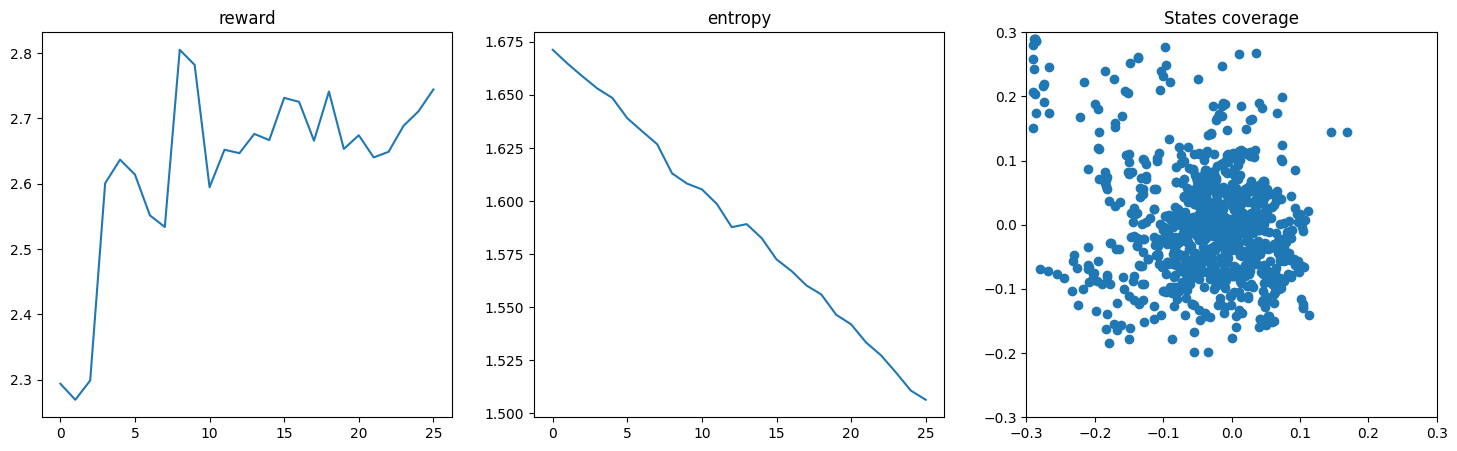

  3%|▎         | 26/1000 [05:29<3:25:46, 12.68s/it]


KeyboardInterrupt: 

In [88]:
for epoch in tqdm(range(1000)):
    z, _ = GMreward.sample(num_envs)
    trajectory = collect_trajectories(env, z, model, n_steps=1000, GMreward=GMreward)
    
    shuffled_trajectory = shufffle_trajectory(trajectory)
    
    for _  in range(5):
        entropy = ppo_optimization(shuffled_trajectory, model, optimizer, epochs=1, batch_size=512)


    
    # GMreward.add(shuffled_trajectory['states'][:, :2])
    
    
    
    # avg_reward = trajectory['rewards'][trajectory['dones'].bool()].mean()
    # avg_reward = trajectory['rewards'][::len(trajectory['rewards'])//num_envs].mean()
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()
    # avg_reward = trajectory['rewards'].mean()
    # avg_reward = get_reward_from_trajectory(trajectory)

    rewards_list.append(avg_reward)
    entropies.append(entropy)

    if epoch % 1 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))
        axs[0].plot(rewards_list)
        axs[0].set_title('reward')
        axs[1].plot(entropies)
        axs[1].set_title('entropy')
        
        # coords = torch.stack([random.choice(GMreward.buffer) for _ in range(1000)])
        coords = shuffled_trajectory['states'][torch.randint(0, len(shuffled_trajectory['states']), (1000,))][:, :2]
        # grid_indices = ((coords - torch.tensor([x_min, y_min])) / grid_size).long()
        # for i, j in grid_indices:
        #     occupancy_grid[i, j] += 1
        #     occupancy_grid[i, j] = min(occupancy_grid[i, j], 100)
        axs[2].scatter(coords[:, 0], coords[:, 1])
        axs[2].set_xlim([-0.3, 0.3])
        axs[2].set_ylim([-0.3, 0.3])
        # axs[2].imshow(occupancy_grid, cmap='Blues', origin='lower')
        axs[2].set_title('States coverage')
        
        
        plt.show()
                

(-0.3, 0.3)

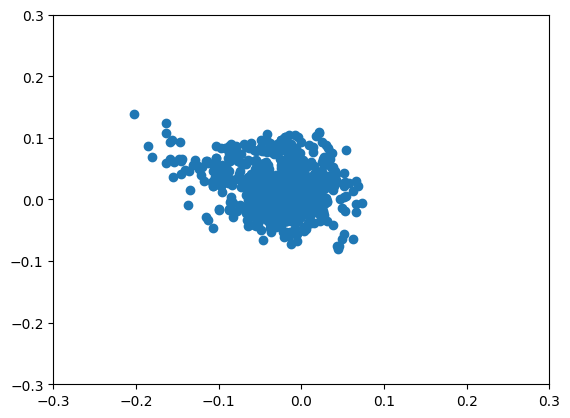

In [ ]:
coords = shuffled_trajectory['states'][torch.randint(0, len(shuffled_trajectory['states']), (1000,))][:, :2]
# grid_indices = ((coords - torch.tensor([x_min, y_min])) / grid_size).long()
# for i, j in grid_indices:
#     occupancy_grid[i, j] += 1
#     occupancy_grid[i, j] = min(occupancy_grid[i, j], 100)
plt.scatter(coords[:, 0], coords[:, 1])
plt.xlim([-0.3, 0.3])
plt.ylim([-0.3, 0.3])
# axs[2].imshow(occupancy_grid, cmap='Blues', origin='lower')
# axs[2].set_title('States coverage')

In [91]:
# eval_num_envs = 16
# eval_env = gym.vector.SyncVectorEnv([lambda: make_env() for _ in tqdm(range(eval_num_envs))])
# eval_env.state_dim = 4
# eval_env.action_dim = 2

GMreward = GuassianMixtureReward(obs_dim=2, num_guassians=5, from_buffer=False)
model = ActorCriticContinuous(
    state_dim=4,
    z_dim=GMreward.len_params,
    action_dim=2,
    actor_hidden_layers=[512, 512, 512, 512],
    critic_hidden_layers=[512, 512, 512, 512]
).to(device)

eval_num_envs = 16
eval_env = TorchWrapper(base_env, num_envs=eval_num_envs)

eval_z, _ = GMreward.sample(eval_num_envs)

trajectories = []
for _ in tqdm(range(1)):
    trajectories.append(collect_trajectories(eval_env, eval_z, model, n_steps=1000, GMreward=GMreward))

  0%|          | 0/1 [00:00<?, ?it/s]/tmp/ipykernel_30305/293159764.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rewards, dones = torch.tensor(rewards), torch.tensor(dones)
100%|██████████| 1/1 [00:13<00:00, 13.89s/it]


100%|██████████| 16/16 [00:01<00:00, 14.95it/s]


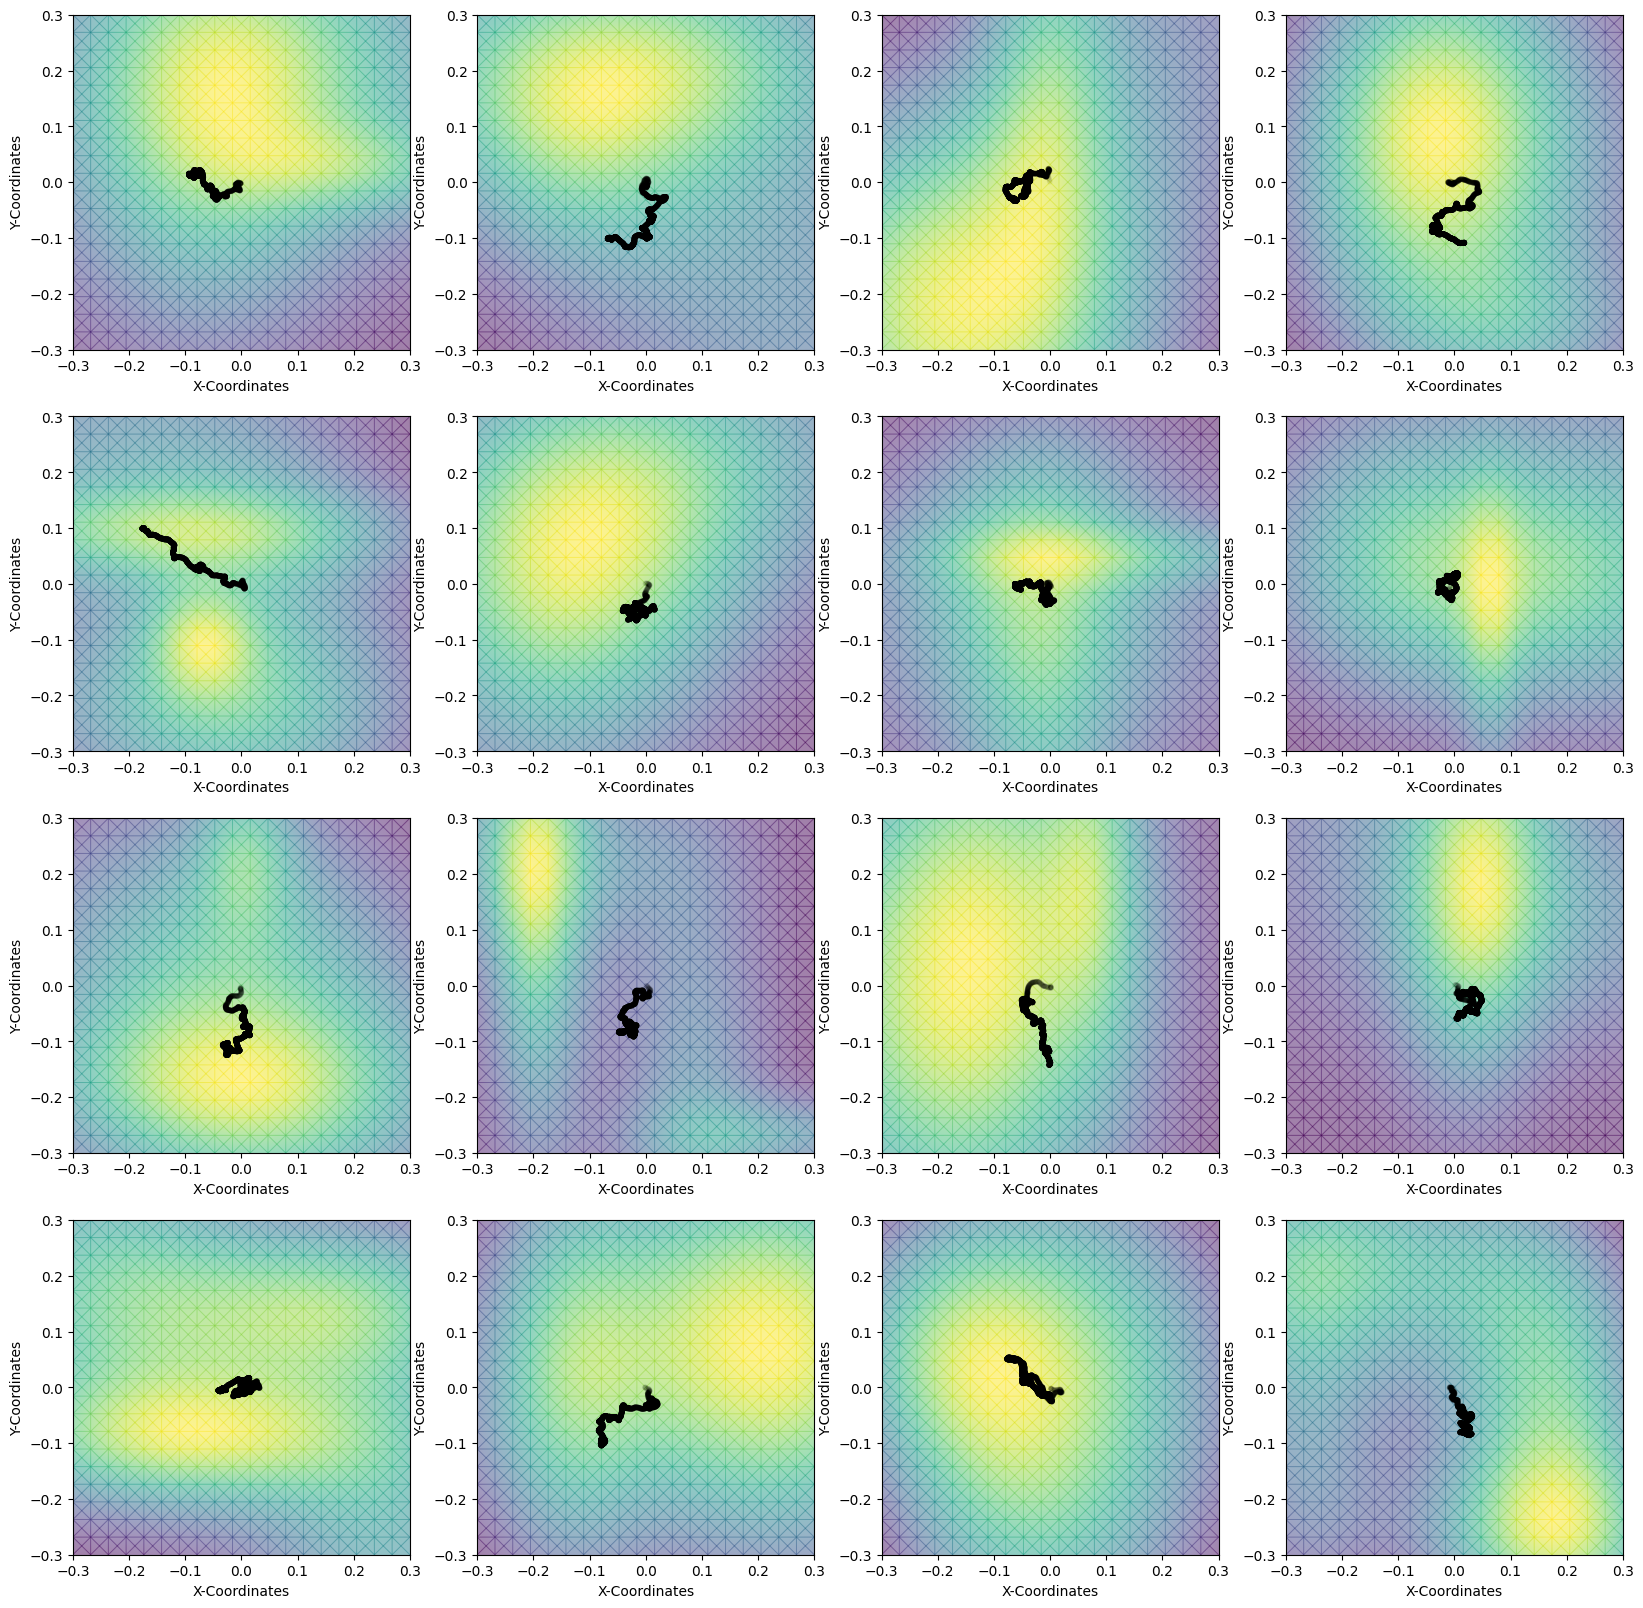

In [92]:
s = 20
x1_vals = np.linspace(-0.3, 0.3, s)
x2_vals = np.linspace(-0.3, 0.3, s)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
# print(X1.shape, X2.shape)

state = torch.rand((s*s, 4)) * 0.6 - 0.3
state[:, :2] = torch.tensor(state_x12)
state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
state = state.to(device)

fig, axs = plt.subplots(4, 4, figsize=(20, 20))
axs = axs.flatten()

for i in tqdm(range(len(eval_z))):
    zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
    r = GMreward.get_reward(state[..., :2], zi).cpu()
    
    
    # axs[i].scatter(state[:, 0], state[:, 1], c=r, alpha=0.3, s=20)
    axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), cmap='viridis', shading='gouraud', alpha=0.5)
    
    for j in range(len(trajectories)):
        trajectory = trajectories[j]
        coords = trajectory['states'][1000*i:1000*(i+1), :2]
        axs[i].scatter(coords[:, 0], coords[:, 1], alpha=np.linspace(0.0, 1, len(coords)), s=10, c='black')
        axs[i].set_xlabel("X-Coordinates")  # Change this to your appropriate label
        axs[i].set_ylabel("Y-Coordinates") 

plt.show()

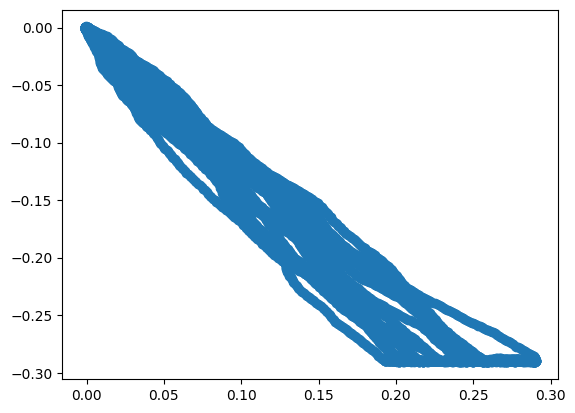

In [ ]:
plt.scatter(trajectory['states'][:, 0], trajectory['states'][:, 1], origin='lower')

In [ ]:
dm_env = suite.load(domain_name="point_mass", task_name="easy")

target_id = 0
xml = resources.GetResource(f'mazes/point_mass_maze_empty.xml')
physics = Physics.from_xml_string(xml, common.ASSETS)
task = MultiTaskPointMassMaze(target_id=target_id)

dm_env = control.Environment(
    physics,
    task,
    time_limit=20,
)


eval_env = DMSuiteEnv(dm_env)
eval_env = FlattenObservation(eval_env)
eval_env = gym.wrappers.TimeLimit(eval_env, max_episode_steps=20)

In [ ]:
c = 0
z, _ = GMreward.sample(1)

def policy_function(time_step):
    global c
    c += 1
    obs = flat_obs(time_step.observation)
    r = GMreward.get_reward(torch.tensor(obs[:2]).unsqueeze(0).float().to(device), z)
    print(r)
    with torch.no_grad():
        action, _, _, dist, _ = model(
            torch.tensor(obs).unsqueeze(0).float().to(device), 
            z.to(device)
        )
        action = dist.loc
        # print(action)
    action = post_process(action)
    action = action[0].cpu().numpy()
    # return env.action_spec().minimum + (env.action_spec().maximum - env.action_spec().minimum) * np.random.rand(*env.action_spec().shape)
    return action

viewer.launch(eval_env.unwrapped.env, policy=policy_function)

tensor([[0.7780]], device='cuda:0')
tensor([[0.7783]], device='cuda:0')
tensor([[0.7789]], device='cuda:0')
tensor([[0.7797]], device='cuda:0')
tensor([[0.7808]], device='cuda:0')
tensor([[0.7822]], device='cuda:0')
tensor([[0.7837]], device='cuda:0')
tensor([[0.7855]], device='cuda:0')
tensor([[0.7875]], device='cuda:0')
tensor([[0.7896]], device='cuda:0')
tensor([[0.7919]], device='cuda:0')
tensor([[0.7943]], device='cuda:0')
tensor([[0.7969]], device='cuda:0')
tensor([[0.7996]], device='cuda:0')
tensor([[0.8025]], device='cuda:0')
tensor([[0.8054]], device='cuda:0')
tensor([[0.8085]], device='cuda:0')
tensor([[0.8116]], device='cuda:0')
tensor([[0.8148]], device='cuda:0')
tensor([[0.8181]], device='cuda:0')
tensor([[0.8215]], device='cuda:0')
tensor([[0.8249]], device='cuda:0')
tensor([[0.8284]], device='cuda:0')
tensor([[0.8319]], device='cuda:0')
tensor([[0.8355]], device='cuda:0')
tensor([[0.8391]], device='cuda:0')
tensor([[0.8427]], device='cuda:0')
tensor([[0.8463]], device='c